In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate random dataset
data = np.random.normal(loc=50, scale=10, size=690)

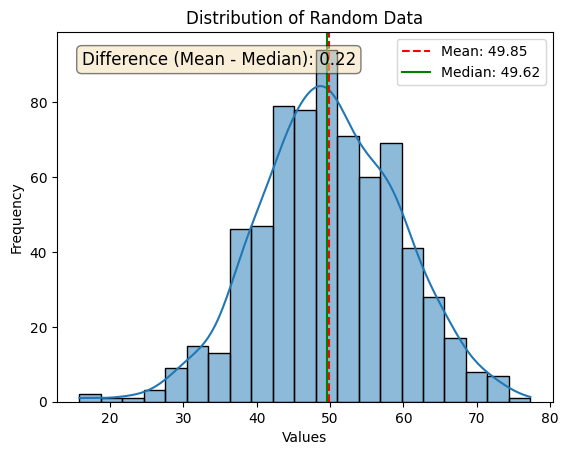

In [5]:
    # Plot the distribution
sns.histplot(data, kde=True)

# Calculate mean and median
mean_val = np.mean(data)
median_val = np.median(data)

# Add vertical lines for mean and median
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

# Add text showing the difference
diff = mean_val - median_val
plt.text(0.05, 0.95, f'Difference (Mean - Median): {diff:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add labels and title
plt.title("Distribution of Random Data")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.legend()

# Show the plot
plt.show()

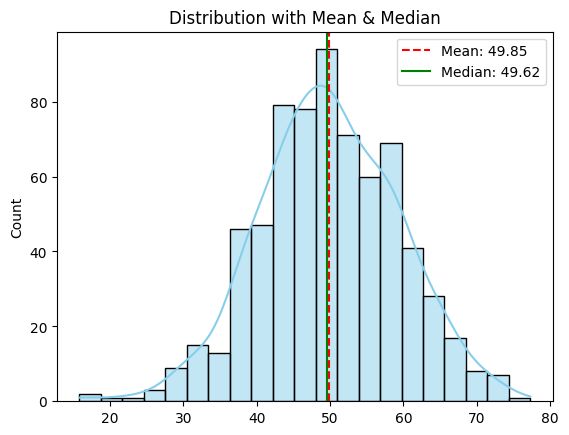

In [4]:
sns.histplot(data, kde=True, color="skyblue")

plt.axvline(np.mean(data), color='red', linestyle='--',
            label=f"Mean: {np.mean(data):.2f}")

plt.axvline(np.median(data), color='green', linestyle='-',
            label=f"Median: {np.median(data):.2f}")

plt.legend()
plt.title("Distribution with Mean & Median")

plt.show()

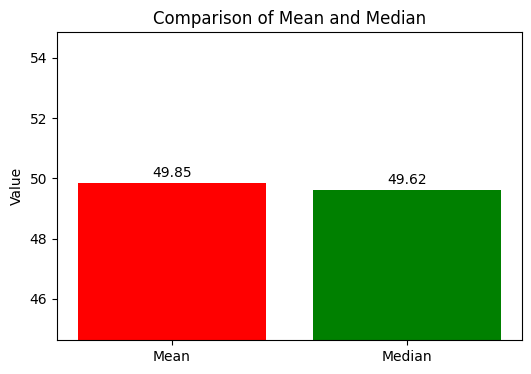

In [6]:
# Separate graph: Bar plot comparing Mean and Median
plt.figure(figsize=(6, 4))
plt.bar(['Mean', 'Median'], [mean_val, median_val], color=['red', 'green'])
plt.title('Comparison of Mean and Median')
plt.ylabel('Value')
plt.ylim(min(mean_val, median_val) - 5, max(mean_val, median_val) + 5)  # Adjust y-axis for better view
for i, v in enumerate([mean_val, median_val]):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom')
plt.show()

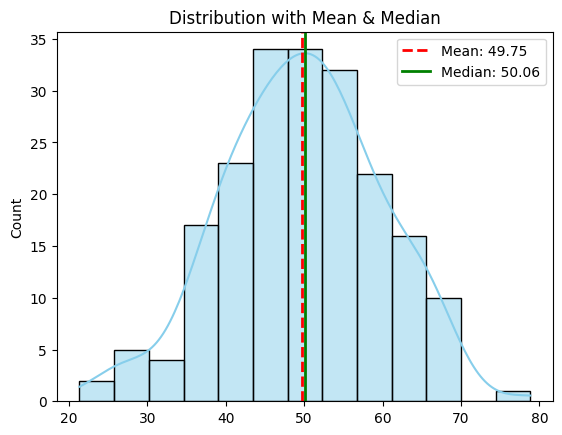

In [8]:
# Generate random dataset
data = np.random.normal(loc=50, scale=10, size=200)

sns.histplot(data, kde=True, color="skyblue")

plt.axvline(np.mean(data), color='red', linestyle='--', linewidth=2,
            label=f"Mean: {np.mean(data):.2f}")

plt.axvline(np.median(data), color='green', linestyle='-', linewidth=2,
            label=f"Median: {np.median(data):.2f}")

plt.legend()
plt.title("Distribution with Mean & Median")

plt.show()

In [9]:

# Hypothesis Testing (t-test, chi-square)
# Use Titanic dataset for real-world context.

import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

# Load Titanic dataset
titanic = sns.load_dataset("titanic")

In [10]:
print(titanic.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [11]:
# Example: Survival by gender

male_surv = titanic[titanic['sex'] == 'male']['survived']
female_surv = titanic[titanic['sex'] == 'female']['survived']

In [12]:
print(titanic.head())   

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [13]:
t_stat, p_val = ttest_ind(male_surv, female_surv, nan_policy='omit')

print(f"T-test: t={t_stat:.2f}, p={p_val:.4f}")

T-test: t=-19.30, p=0.0000


In [14]:
# Chi-square: survival vs class

contingency = pd.crosstab(titanic['class'], titanic['survived'])

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: chi2={chi2:.2f}, p={p:.4f}")

Chi-square: chi2=102.89, p=0.0000
